# Support Vector Regression (SVR)

Support Vector Regression (SVR) is a machine learning algorithm used for predicting continuous values.
It is an extension of Support Vector Machines (SVM), which are typically used for classification, but SVR is designed for regression tasks.

SVR doesn’t try to be perfect,It tries to be close enough within a limit

## Importing the libraries

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [7]:
dataset = pd.read_csv('Position_Salaries.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

In [8]:
dataset.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [10]:
X

array([[ 1],
       [ 2],
       [ 3],
       [ 4],
       [ 5],
       [ 6],
       [ 7],
       [ 8],
       [ 9],
       [10]])

In [11]:
X.shape

(10, 1)

In [12]:
y

array([  45000,   50000,   60000,   80000,  110000,  150000,  200000,
        300000,  500000, 1000000])

In [13]:
y.shape

(10,)

In [14]:
y = y.reshape(len(y),1)

In [15]:
y.shape

(10, 1)

In [16]:
y

array([[  45000],
       [  50000],
       [  60000],
       [  80000],
       [ 110000],
       [ 150000],
       [ 200000],
       [ 300000],
       [ 500000],
       [1000000]])

Reshape is used in SVR to convert 1D data into 2D format because the model expects data in a table format, not a simple list..

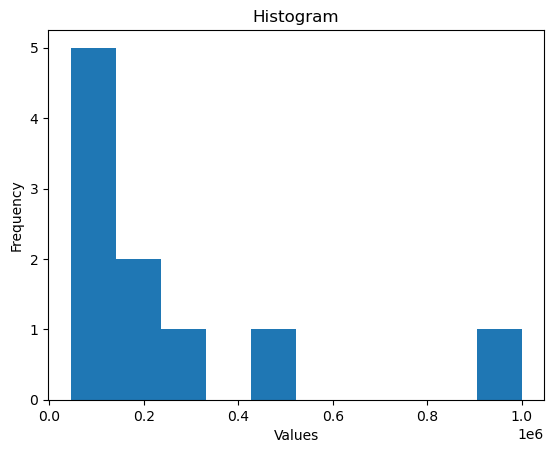

In [17]:
import matplotlib.pyplot as plt

plt.hist(dataset['Salary'])
plt.title("Histogram")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.show()

## Feature Scaling

Feature scaling = making all features equally important.
It balances all feature values so no single feature dominates the model.

In [18]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
scaled_X = sc_X.fit_transform(X)
scaled_y = sc_y.fit_transform(y)

In [19]:
scaled_X

array([[-1.5666989 ],
       [-1.21854359],
       [-0.87038828],
       [-0.52223297],
       [-0.17407766],
       [ 0.17407766],
       [ 0.52223297],
       [ 0.87038828],
       [ 1.21854359],
       [ 1.5666989 ]])

In [20]:
scaled_y

array([[-0.72004253],
       [-0.70243757],
       [-0.66722767],
       [-0.59680786],
       [-0.49117815],
       [-0.35033854],
       [-0.17428902],
       [ 0.17781001],
       [ 0.88200808],
       [ 2.64250325]])

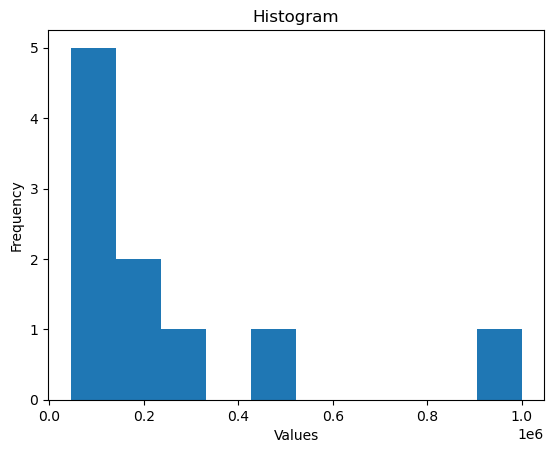

In [21]:
import matplotlib.pyplot as plt

plt.hist(dataset['Salary'])
plt.title("Histogram")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.show()

**Feature scaling changes values but not the relationship, so correlation remains the same.**

    **Correlation does NOT change after feature scaling ✅**

### Before Scaled

In [22]:
df_X = pd.DataFrame(X, columns=['X'])
df_y = pd.DataFrame(y, columns=['y'])

In [23]:
con = df_X.join(df_y)

In [24]:
con

,X,y
0,1,45000
1,2,50000
2,3,60000
3,4,80000
4,5,110000
5,6,150000
6,7,200000
7,8,300000
8,9,500000
9,10,1000000


In [25]:
con.corr()

,X,y
X,1.000000,0.817949
y,0.817949,1.000000


### After Scaled

In [26]:
df_scaled_X = pd.DataFrame(scaled_X, columns=['X'])
df_scaled_y = pd.DataFrame(scaled_y, columns=['y'])

In [27]:
df_scaled_X

,X
0,-1.566699
1,-1.218544
2,-0.870388
3,-0.522233
4,-0.174078
5,0.174078
6,0.522233
7,0.870388
8,1.218544
9,1.566699


In [28]:
df_scaled_y

,y
0,-0.720043
1,-0.702438
2,-0.667228
3,-0.596808
4,-0.491178
5,-0.350339
6,-0.174289
7,0.177810
8,0.882008
9,2.642503


In [29]:
scaled_con = df_scaled_X.join(df_scaled_y)

In [30]:
scaled_con

,X,y
0,-1.566699,-0.720043
1,-1.218544,-0.702438
2,-0.870388,-0.667228
3,-0.522233,-0.596808
4,-0.174078,-0.491178
5,0.174078,-0.350339
6,0.522233,-0.174289
7,0.870388,0.177810
8,1.218544,0.882008
9,1.566699,2.642503


In [31]:
scaled_con.corr()

,X,y
X,1.000000,0.817949
y,0.817949,1.000000


**Both outputs will be same**

## Training the SVR model on the whole dataset

In [32]:
from sklearn.svm import SVR
regressor = SVR(kernel = 'rbf')
#y=column_or_1d(y,warn=True)
regressor.fit(scaled_X, scaled_y.ravel())
print(scaled_y)
print(scaled_y.ravel())

[[-0.72004253]
 [-0.70243757]
 [-0.66722767]
 [-0.59680786]
 [-0.49117815]
 [-0.35033854]
 [-0.17428902]
 [ 0.17781001]
 [ 0.88200808]
 [ 2.64250325]]
[-0.72004253 -0.70243757 -0.66722767 -0.59680786 -0.49117815 -0.35033854
 -0.17428902  0.17781001  0.88200808  2.64250325]


## Predicting a new result

After training the model, you use .predict() to get a new value.

In [71]:
x1=regressor.predict(sc_X.transform([[3]]))
#x1.shape
x1
y1=sc_y.inverse_transform(x1.reshape(-1,1))
y1

array([[88213.00902103]])

array([[  45000],
       [  50000],
       [  60000],
       [  80000],
       [ 110000],
       [ 150000],
       [ 200000],
       [ 300000],
       [ 500000],
       [1000000]])

## Visualising the SVR results

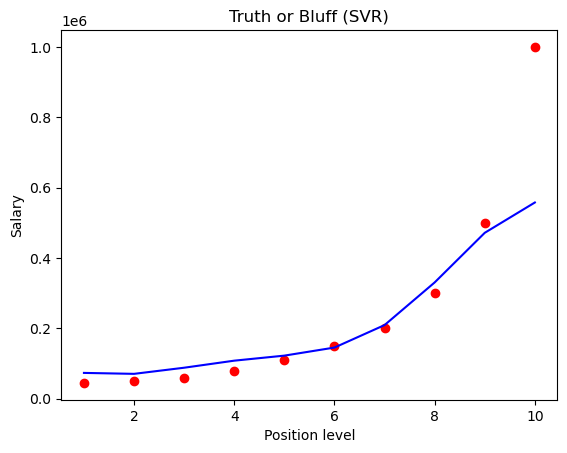

In [40]:
plt.scatter(sc_X.inverse_transform(scaled_X), sc_y.inverse_transform(scaled_y), color = 'red')
plt.plot(sc_X.inverse_transform(scaled_X), sc_y.inverse_transform(regressor.predict(scaled_X).reshape(-1,1)), color = 'blue')
plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

## Visualising the SVR results (for higher resolution and smoother curve)

C:\Users\Admin\AppData\Local\Temp\ipykernel_12804\1990856058.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(sc_X.inverse_transform(scaled_X)), max(sc_X.inverse_transform(scaled_X)), 0.1)


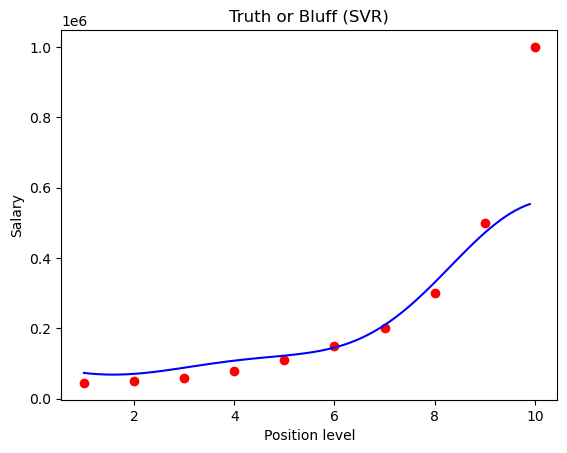

In [41]:
X_grid = np.arange(min(sc_X.inverse_transform(scaled_X)), max(sc_X.inverse_transform(scaled_X)), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(sc_X.inverse_transform(scaled_X), sc_y.inverse_transform(scaled_y), color = 'red')
plt.plot(X_grid, sc_y.inverse_transform(regressor.predict(sc_X.transform(X_grid)).reshape(-1,1)), color = 'blue')
plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

In [42]:
X_grid

array([[1. ],
       [1.1],
       [1.2],
       [1.3],
       [1.4],
       [1.5],
       [1.6],
       [1.7],
       [1.8],
       [1.9],
       [2. ],
       [2.1],
       [2.2],
       [2.3],
       [2.4],
       [2.5],
       [2.6],
       [2.7],
       [2.8],
       [2.9],
       [3. ],
       [3.1],
       [3.2],
       [3.3],
       [3.4],
       [3.5],
       [3.6],
       [3.7],
       [3.8],
       [3.9],
       [4. ],
       [4.1],
       [4.2],
       [4.3],
       [4.4],
       [4.5],
       [4.6],
       [4.7],
       [4.8],
       [4.9],
       [5. ],
       [5.1],
       [5.2],
       [5.3],
       [5.4],
       [5.5],
       [5.6],
       [5.7],
       [5.8],
       [5.9],
       [6. ],
       [6.1],
       [6.2],
       [6.3],
       [6.4],
       [6.5],
       [6.6],
       [6.7],
       [6.8],
       [6.9],
       [7. ],
       [7.1],
       [7.2],
       [7.3],
       [7.4],
       [7.5],
       [7.6],
       [7.7],
       [7.8],
       [7.9],
       [8. ],
      

## predict

In [72]:
y

array([[  45000],
       [  50000],
       [  60000],
       [  80000],
       [ 110000],
       [ 150000],
       [ 200000],
       [ 300000],
       [ 500000],
       [1000000]])

In [73]:
x1=regressor.predict(sc_X.transform([[3]]))
#x1.shape
x1
y1=sc_y.inverse_transform(x1.reshape(-1,1))
y1

array([[88213.00902103]])

C:\Users\Admin\AppData\Local\Temp\ipykernel_12804\3472621849.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(sc_X.inverse_transform(scaled_X)),15, 0.1)


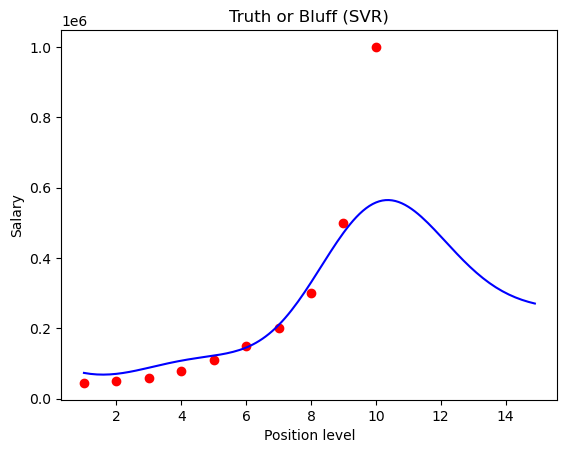

In [76]:
X_grid = np.arange(min(sc_X.inverse_transform(scaled_X)),15, 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(sc_X.inverse_transform(scaled_X), sc_y.inverse_transform(scaled_y), color = 'red')
plt.plot(X_grid, sc_y.inverse_transform(regressor.predict(sc_X.transform(X_grid)).reshape(-1,1)), color = 'blue')
plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()